In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [12]:
df=pd.read_csv("Score.csv")
df

,Hours Studied,Attendance,Assignments Completed,Co-curricular Activities,Exam Score
0,2,75,5,Yes,48
1,3,80,6,Yes,55
2,4,82,7,No,60
3,5,85,8,Yes,68
4,6,88,8,Yes,72
5,6,90,9,No,75
6,7,91,9,No,80
7,8,93,10,Yes,86
8,9,95,10,No,91
9,10,98,10,Yes,96


In [20]:
df.columns

Index(['Hours Studied', 'Attendance', 'Assignments Completed',
       'Co-curricular Activities', 'Exam Score'],
      dtype='str')

In [21]:
df.isnull().sum()

Hours Studied               0
Attendance                  0
Assignments Completed       0
Co-curricular Activities    0
Exam Score                  0
dtype: int64

In [22]:
df["Co-curricular Activities"]=pd.get_dummies(df["Co-curricular Activities"],drop_first=True,dtype=int)

In [23]:
df

,Hours Studied,Attendance,Assignments Completed,Co-curricular Activities,Exam Score
0,2,75,5,1,48
1,3,80,6,1,55
2,4,82,7,0,60
3,5,85,8,1,68
4,6,88,8,1,72
5,6,90,9,0,75
6,7,91,9,0,80
7,8,93,10,1,86
8,9,95,10,0,91
9,10,98,10,1,96


<Axes: xlabel='Attendance', ylabel='Exam Score'>

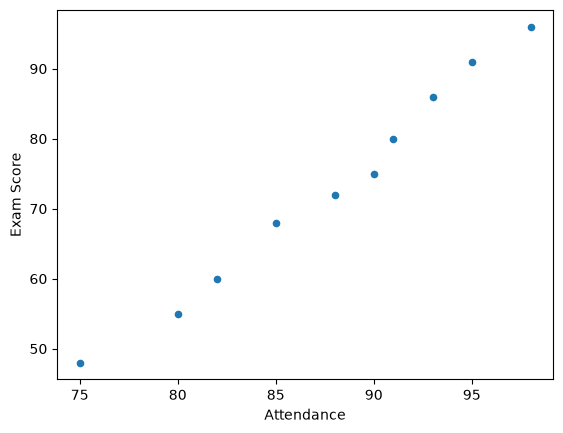

In [24]:
df.plot(kind="scatter",x="Attendance",y="Exam Score")

In [25]:
df.shape

(10, 5)

In [26]:
x=df.drop(columns="Exam Score")

In [27]:
x.shape

(10, 4)

In [28]:
y=df[["Exam Score"]]

In [29]:
y.shape

(10, 1)

In [30]:
#splitting the data into train and test set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [31]:
x_train.shape

(7, 4)

In [32]:
y_train.shape

(7, 1)

In [33]:
y_test.shape

(3, 1)

In [34]:
x_test.shape

(3, 4)

In [35]:
#create the model
model=LinearRegression()

In [36]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[ 5.63,-0.29, 1.99, 0.03]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Hours Studied','Attendance','Assignments Completed', 'Co-curricular Activities']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[47.8]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [37]:
#use the trained model to predict the test data
y_pred=model.predict(x_test)

In [38]:
print("Mean squared error")
print(mean_squared_error(y_test,y_pred))
print("R_Squared")
print(r2_score(y_test,y_pred))
print("Mean absolute error")
print(mean_absolute_error(y_test,y_pred))

Mean squared error
0.9527966782419156
R_Squared
0.9956069825285977
Mean absolute error
0.87432498772705


In [39]:
x_new=[[6,80,10,1]]

In [40]:
pred_new=model.predict(x_new)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [41]:
pred_new

array([[78.6921944]])